# Multi-Head Latent Attention (Deepseek v2)
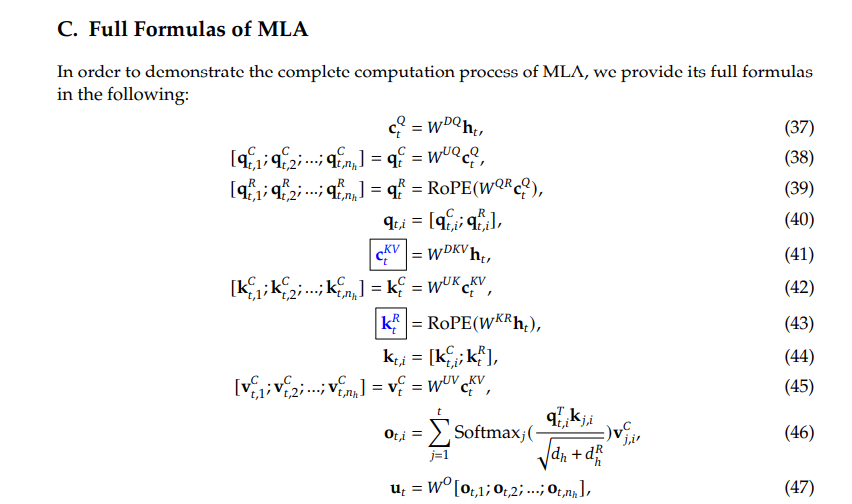

In [1]:
import math
import torch

In [14]:
def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

def apply_rope(q, k, cos, sin):
    q = (q * cos) + (rotate_half(q) * sin)
    k = (k * cos) + (rotate_half(k) * sin)
    return q, k

def apply_rope_x(x, cos, sin):
    return (x * cos) + (rotate_half(x) * sin)

In [4]:
class RoPElessMLA(torch.nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.q_proj_dim = d_model//2 #compressed dim for queries
        self.kv_proj_dim = (2*d_model)/3 #compressed dim for key/values
        self.dh = d_model // n_heads #dim per head
        

        # PROJECTION MATRICES

        self.W_dq = torch.nn.Parameter(0.01*torch.randn((d_model, self.q_proj_dim))) # compression
        self.W_uq = torch.nn.Parameter(0.01*torch.randn((self.q_proj_dim, d_model))) # decompression
        self.q_layernorm = torch.nn.LayerNorm(self.q_proj_dim) # Why LayerNorm only?

        # KV Projections

        self.W_dkv = torch.nn.Parameter(0.01*torch.randn(d_model, self.kv_proj_dim)) # compression of both K and V
        self.W_ukv = torch.nn.Parameter(0.01*((self.kv_proj_dim, 2*self.d_model))) # decompression
        self.kv_layernorm = torch.nn.LayerNorm(self.kv_proj_dim)

        # output projection

        self.W_o = torch.nn.Parameter(0.01*torch.randn((d_model, d_model))) # combines everything to the final output

In [7]:
def forward(self, x, kv_cache=None, past_length=0):
    B_size, S_lngth, D = x.size() # Batch Size, Sequence Length, Dimension

    # Q Projections
    compressed_q = x @ self.W_dq # take each word and compress it's information
    compressed_q = self.q_layernorm(compressed_q) # making sure the compressed info is balanced
    Q = compressed_q @ self.W_uq # expanding it back

    # KV Projection

    # so it's like if we haven't stored any prev info and KV cache is None  -> we'll compress the current info and balance ir.
    if kv_cache is None:
        compressed_kv = x @ self.W_dkv
        compressed_kv = self.kv_layernorm(compressed_kv)


    # if we've stored the info -> compress only the new info -> add it to our stored info
    else:
        new_kv = x @ self.W_dkv
        new_kv = self.kv_layernorm(new_kv)
        compressed_kv = torch.cat([kv_cache, new_kv], dim=1)


    # splitting info into multiple heads

    KV = compressed_kv @ self.W_ukv
    K, V = torch.split(KV, self.d_model, dim=1)

    q_heads = Q.view(B_size, -1, self.n_heads, self.dh).transpose(1, 2)
    k_heads = K.view(B_size, -1, self.n_heads, self.dh).transpose(1, 2)
    v_heads = V.view(B_size, -1, self.n_heads, self.dh).transpose(1, 2)

    # let's consider S_full as total length of our sequence including any past cached information

    S_full = k_heads.size(2)

    # creating the attention mask

    mask = torch.ones((S, S_full), device=x.device)
    mask = torch.tril(mask, diagonal=past_length)
    mask = mask[None, None, :, :]

    sq_mask = mask == 1

    # attention

    # for each Query (what we are looking for) -> we compare it with all the Keys (what information we have) -> then we use these comparisons to weight the Values
    # Attention(Q,K,V) = softmax(QK^T/√d_k)V

    x = torch.nn.functional.scaled_dot_product_attention(q_heads, k_heads, v_heads, attn_mask=sq_mask)
    
    # Reshaping the output (we're putting it back together)
    # We go from (Batch, Heads, Sequence, Head_Dimension) to (Batch, Sequence, Model_Dimension)

    x = x.transpose(1, 2).reshape(B_size, S_lngth, D)

    # apply projection

    x = x @ self.W_o.T

    # return values

    return x, compressed_kv


## MLA + RoPE

In [11]:
class MLA(torch.nn.Module):
    def __init__(self, d_model, n_heads, max_len=1024, rope_theta=10000.0):
        super().__init__()
        # still we are keeping our basic dimensions like before only
        self.d_model = d_model
        self.n_heads = n_heads
        self.dh = d_model//n_heads
        self.q_proj_dim = d_model//2
        self.kv_proj_dim = (2*d_model)//3

        # for RoPE
        # splitting each head's dimension into two parts
        self.qk_nope_dim = self.dh//2 # half will use regular attention
        self.qk_rope_dim = self.dh//2 # half will use position-aware attention

        # Q Projections (same as RoPEless)
        # LORA
        self.W_dq = torch.nn.Parameter(0.01*torch.randn((d_model, self.q_proj_dim))) # compression
        self.W_uq = torch.nn.Parameter(0.01*torch.randn((self.q_proj_dim, d_model))) # decompression
        self.q_layernorm = torch.nn.LayerNorm(self.q_proj_dim)

        # KV Projections
        # LORA
        self.W_dkv = torch.nn.Parameter(0.01*torch.rand((d_model, self.kv_proj_dim + self.qk_rope_dim)))
        self.W_ukv = torch.nn.Parameter(0.01*torch.randn((self.kv_proj_dim, self.d_model + (self.n_heads * self.qk_nope_dim))))
        self.kv_layernorm = torch.nn.LayerNorm(self.kv_proj_dim)

        # output projection

        self.W_o = torch.nn.Parameter(0.01*torch.randn(d_model, d_model))


        # RoPE
        self.max_seq_len = max_len
        self.rope_theta = rope_theta

        '''RoPE is a way to give each position in our sequence a unique "angle"
        The angle changes based on position and frequency,
        We pre-calculate sin/cos values for efficiency,
        Different positions get different rotations, helping the model understand order'''

        freqs = 1.0 / (rope_theta ** (torch.arange(0, self.dh, 2).float() / self.dh))
        emb = torch.outer(torch.arange(self.max_seq_len).float(), freqs)
        cos_cached = emb.cos()[None, None, :, :]
        sin_cached = emb.sin()[None, None, :, :]

In [16]:
def forward(self, x, kv_cache=None, past_length=0):

    B_size, S_lngth, D = x.size() # Batch Size, Sequence Length, Dimension

    # Q Projections with RoPE splitting

    # here we compress queries like before but now split them into two parts
    # - Q : regular attention part
    # - Q_for_rope: part that will get position info

    compressed_q = x @ self.W_dq
    compressed_q = self.q_layernorm(compressed_q)
    Q = compressed_q @ self.W_uq

    Q = Q.view(B_size, -1, self.n_heads, self.dh).transpose(1, 2)
    Q, Q_for_rope = torch.split(Q, [self.qk_nope_dim, self.qk_rope_dim], dim = -1)


    # Q Decopuled RoP

    '''
    this is like - get the right rotation angles for our current positions
    apply these rotations for half of our query vectors
    the rotation gives position a unique signature
    '''
    cos_q = self.cos_cached[:, :, past_length:past_length+S, :self.qk_rope_dim//2].repeat(1, 1, 1, 2)
    sin_q = self.sin_cached[:, :, past_length:past_length+S, :self.qk_rope_dim//2].repeat(1, 1, 1, 2)
    Q_for_rope = apply_rope_x(Q_for_rope, cos_q, sin_q)

    # KV Projections with RoPE

    '''
    We split the KV projections into two parts:Regular part (KV_for_lora), RoPE part (K_for_rope)
    Only apply layer norm to the regular part
    '''
    if kv_cache is None:
        compressed_kv = x @ self.W_dkv
        KV_for_lora, K_for_rope = torch.split(compressed_kv,
                                                  [self.kv_proj_dim, self.qk_rope_dim],
                                                  dim=-1)
        KV_for_lora = self.kv_layernorm(KV_for_lora)
    else:
        new_kv = x @ self.W_dkv
        compressed_kv = torch.cat([kv_cache, new_kv], dim=1)
        new_kv, new_K_for_rope = torch.split(new_kv,
                                                 [self.kv_proj_dim, self.qk_rope_dim],
                                                 dim=-1)
        old_kv, old_K_for_rope = torch.split(kv_cache,
                                                 [self.kv_proj_dim, self.qk_rope_dim],
                                                 dim=-1)
        new_kv = self.kv_layernorm(new_kv)
        old_kv = self.kv_layernorm(old_kv)
        KV_for_lora = torch.cat([old_kv, new_kv], dim=1)
        K_for_rope = torch.cat([old_K_for_rope, new_K_for_rope], dim=1)


    KV = KV_for_lora @ self.W_ukv
    KV = KV.view(B, -1, self.n_heads, self.dh+self.qk_nope_dim).transpose(1,2)
    K, V = torch.split(KV, [self.qk_nope_dim, self.dh], dim=-1)
    S_full = K.size(2)

    # K Rope
    K_for_rope = K_for_rope.view(B, -1, 1, self.qk_rope_dim).transpose(1,2)
    cos_k = self.cos_cached[:, :, :S_full, :self.qk_rope_dim//2].repeat(1, 1, 1, 2)
    sin_k = self.sin_cached[:, :, :S_full, :self.qk_rope_dim//2].repeat(1, 1, 1, 2)
    K_for_rope = apply_rope_x(K_for_rope, cos_k, sin_k)

    # apply position encoding to each head
    K_for_rope = K_for_rope.repeat(1, self.n_heads, 1, 1)

    # split into multiple heads
    q_heads = torch.cat([Q, Q_for_rope], dim=-1)
    k_heads = torch.cat([K, K_for_rope], dim=-1)
    v_heads = V # already reshaped before the split

    # make attention mask
    mask = torch.ones((S,S_full), device=x.device)
    mask = torch.tril(mask, diagonal=past_length)
    mask = mask[None, None, :, :]

    sq_mask = mask == 1


    # attention
    x = torch.nn.functional.scaled_dot_product_attention(q_heads, k_heads, v_heads, attn_mask=sq_mask)       

    x = x.transpose(1, 2).reshape(B_size, S_lngth, D) 

    # apply projection

    x = x @ self.W_o.T

    return x, compressed_kv